# RSNA Pneumonia — Notebook 1 : Préparation des données + entraînement YOLO26x

Pipeline modulaire en 2 étapes (approche parallèle) :
1. **YOLO26x** détecte les opacités (bounding boxes) — *ce notebook*.
2. **MedGemma 1.5 4B** décrit les détections — *notebook 2*.

Ce notebook : conversion DICOM→image (CLAHE), conversion des boxes au format YOLO,
split stratifié, entraînement `yolo26x` @ 1024, évaluation (mAP) + visualisation.

**Config choisie** : yolo26x @ 1024 · dataset équilibré (tous positifs + autant de négatifs) · 1 classe `pneumonia`.

### Prérequis Kaggle
- **Accélérateur** : GPU T4 (Settings → Accelerator).
- **Internet** : activé (pip + téléchargement des poids YOLO26).
- **Dataset** : ajoute *RSNA Pneumonia Detection Challenge*.

> Exécute les cellules de haut en bas.

In [14]:
# --- Installations (Kaggle) ---
# Ultralytics apporte le support YOLO26. On (re)fige Pillow 11.3.0 APRÈS coup :
# un upgrade casse l'extension _imaging sur l'image Kaggle.
!pip install -q -U ultralytics
!pip install -q pydicom
!pip install -q --force-reinstall --no-deps "pillow==11.3.0"

In [15]:
import os, glob, random, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import cv2, pydicom
from tqdm.auto import tqdm
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import matplotlib.patches as patches

warnings.filterwarnings("ignore")
SEED = 42
random.seed(SEED); np.random.seed(SEED)

# --- Chemins RSNA (le dossier varie selon la façon dont le dataset est ajouté) ---
CANDIDATES = [
    "/kaggle/input/rsna-pneumonia-detection-challenge",
    "/kaggle/input/competitions/rsna-pneumonia-detection-challenge",
]
BASE_DIR = next((p for p in CANDIDATES if os.path.exists(p)), None)
assert BASE_DIR is not None, "Dataset RSNA introuvable — vérifie l'ajout du dataset."
print("BASE_DIR :", BASE_DIR)

TRAIN_DCM_DIR = os.path.join(BASE_DIR, "stage_2_train_images")
CLASS_CSV     = os.path.join(BASE_DIR, "stage_2_detailed_class_info.csv")
LABELS_CSV    = os.path.join(BASE_DIR, "stage_2_train_labels.csv")

# --- Sortie / paramètres ---
OUT_DIR       = Path("/kaggle/working/rsna_yolo")
IMG_SIZE_SAVE = 1024          # on sauvegarde en résolution native
IMGSZ_TRAIN   = 1024          # résolution d'entraînement YOLO
VAL_FRAC      = 0.15          # split 85/15
CLAHE_CLIP    = 2.0
CLAHE_GRID    = (8, 8)

for sub in ["images/train", "images/val", "labels/train", "labels/val"]:
    (OUT_DIR / sub).mkdir(parents=True, exist_ok=True)

BASE_DIR : /kaggle/input/competitions/rsna-pneumonia-detection-challenge


In [16]:
df_cls = pd.read_csv(CLASS_CSV)
df_box = pd.read_csv(LABELS_CSV)
print(df_box.Target.value_counts(), "\n")
print(df_cls["class"].value_counts())

# Boxes groupées par patient (une ligne = une box quand Target==1)
pos_boxes = (df_box[df_box.Target == 1]
             .groupby("patientId")[["x", "y", "width", "height"]]
             .apply(lambda g: g.values.tolist())
             .to_dict())

pos_ids = sorted(pos_boxes.keys())                              # patients AVEC opacité
neg_ids = sorted(df_box.loc[df_box.Target == 0, "patientId"].unique())
print(f"\nPositifs : {len(pos_ids)} · Négatifs disponibles : {len(neg_ids)}")

Target
0    20672
1     9555
Name: count, dtype: int64 

class
No Lung Opacity / Not Normal    11821
Lung Opacity                     9555
Normal                           8851
Name: count, dtype: int64

Positifs : 6012 · Négatifs disponibles : 20672


In [17]:
# Dataset équilibré : tous les positifs + autant de négatifs (échantillonnés)
random.shuffle(neg_ids)
neg_sel  = neg_ids[:len(pos_ids)]
selected = [(pid, 1) for pid in pos_ids] + [(pid, 0) for pid in neg_sel]
random.shuffle(selected)
print(f"Total sélectionné : {len(selected)} images "
      f"({len(pos_ids)} positifs + {len(neg_sel)} négatifs)")

Total sélectionné : 12024 images (6012 positifs + 6012 négatifs)


In [18]:
def dicom_to_rgb(dcm_path, size=IMG_SIZE_SAVE):
    # DICOM -> normalisation Min-Max 8 bits -> CLAHE -> RGB (prétraitement cohérent)
    dcm = pydicom.dcmread(dcm_path)
    img = dcm.pixel_array.astype(np.float32)
    img = (img - img.min()) / (img.max() - img.min() + 1e-8)
    img = (img * 255.0).astype(np.uint8)
    if img.shape[0] != size:
        img = cv2.resize(img, (size, size), interpolation=cv2.INTER_AREA)
    clahe = cv2.createCLAHE(clipLimit=CLAHE_CLIP, tileGridSize=CLAHE_GRID)
    img = clahe.apply(img)
    return cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)   # HxWx3


def boxes_to_yolo(boxes, img_size=1024):
    # (x, y, w, h) pixels sur 1024 -> lignes YOLO "classe cx cy w h" normalisées
    lines = []
    for (x, y, w, h) in boxes:
        cx = (x + w / 2) / img_size
        cy = (y + h / 2) / img_size
        lines.append(f"0 {cx:.6f} {cy:.6f} {w/img_size:.6f} {h/img_size:.6f}")
    return lines

In [19]:
# Split stratifié par présence d'opacité
ids  = [pid for pid, _ in selected]
labs = [lab for _, lab in selected]
tr_ids, va_ids = train_test_split(ids, test_size=VAL_FRAC,
                                  stratify=labs, random_state=SEED)
split_of = {pid: "train" for pid in tr_ids}
split_of.update({pid: "val" for pid in va_ids})
print(f"train : {len(tr_ids)} · val : {len(va_ids)}")

def materialize(pid):
    split = split_of[pid]
    dcm   = os.path.join(TRAIN_DCM_DIR, pid + ".dcm")
    rgb   = dicom_to_rgb(dcm)
    cv2.imwrite(str(OUT_DIR / "images" / split / f"{pid}.png"), rgb)
    # label : lignes si positif, fichier vide si négatif (background)
    boxes = pos_boxes.get(pid, [])
    lines = boxes_to_yolo(boxes) if boxes else []
    (OUT_DIR / "labels" / split / f"{pid}.txt").write_text("\n".join(lines))

for pid, _ in tqdm(selected, desc="DICOM->PNG + labels"):
    materialize(pid)
print("Conversion terminée.")

train : 10220 · val : 1804


DICOM->PNG + labels:   0%|          | 0/12024 [00:00<?, ?it/s]

Conversion terminée.


In [20]:
data_yaml = OUT_DIR / "data.yaml"
data_yaml.write_text(
    f"path: {OUT_DIR}\n"
    "train: images/train\n" 
    "val: images/val\n"
    "nc: 1\n"
    "names: ['pneumonia']\n"
)
print(data_yaml.read_text())

path: /kaggle/working/rsna_yolo
train: images/train
val: images/val
nc: 1
names: ['pneumonia']



In [21]:
from ultralytics import YOLO

model = YOLO("yolo26m.pt")           # m au lieu de x
model.train(
    data=str(data_yaml),
    imgsz=640,                       # 640 au lieu de 1024
    batch=16,
    time=0.5,                        # BUDGET horaire : 0.5 = 30 min, 1.0 = 1 h (remplace epochs)
    device=1,                        # -> [0, 1] pour 2 T4 (encore ~÷2)
    workers=2,
    cache=False,
    close_mosaic=10,
    project="/kaggle/working/runs",
    name="yolo26m_rsna_fast",
    exist_ok=True,
    seed=SEED,
)

Ultralytics 8.4.84 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:1 (Tesla T4, 14912MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/rsna_yolo/data.yaml, degrees=0.0, deterministic=True, device=1, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26m.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolo26m_rsna_fast, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7fcdfffc0230>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.048048, 

### Reprise après coupure de session
Si Kaggle stoppe avant la fin, relance depuis le dernier checkpoint :
```python
model = YOLO("/kaggle/working/runs/yolo26x_rsna/weights/last.pt")
model.train(resume=True)
```

In [22]:
metrics = model.val()
print(f"mAP@50    : {metrics.box.map50:.4f}")
print(f"mAP@50-95 : {metrics.box.map:.4f}")

Ultralytics 8.4.84 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
YOLO26m summary (fused): 132 layers, 20,350,223 parameters, 0 gradients, 67.8 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2588.0±1430.4 MB/s, size: 1338.7 KB)
val: Scanning /kaggle/working/rsna_yolo/labels/val.cache... 1804 images, 902 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1804/1804 540.5Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 113/113 2.0it/s 57.0s0.5s
                   all       1804       1425      0.446      0.455      0.415       0.14
Speed: 1.3ms preprocess, 28.1ms inference, 0.0ms loss, 0.1ms postprocess per image
Results saved to /kaggle/working/runs/detect/val
mAP@50    : 0.4153
mAP@50-95 : 0.1402


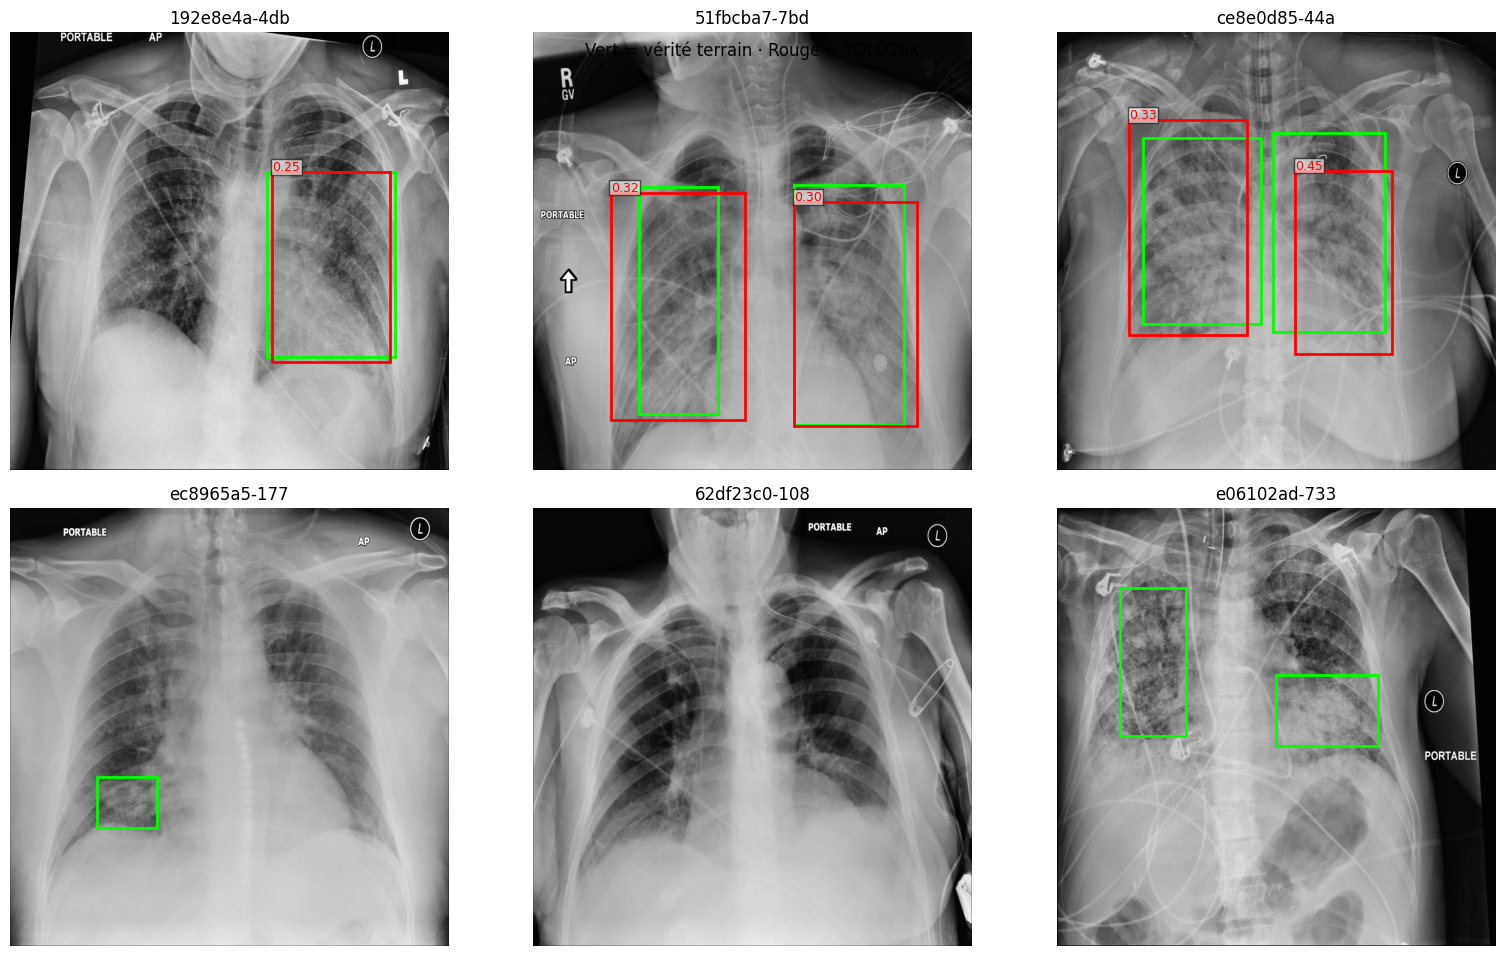

In [26]:
# Visualisation : boxes prédites (rouge) vs réelles (vert) sur des images de val
val_imgs = sorted(glob.glob(str(OUT_DIR / "images/val/*.png")))
random.shuffle(val_imgs)
show = val_imgs[:6]

def gt_boxes_for(img_path):
    pid = Path(img_path).stem
    lbl = OUT_DIR / "labels/val" / f"{pid}.txt"
    out = []
    if lbl.exists() and lbl.read_text().strip():
        for line in lbl.read_text().strip().splitlines():
            _, cx, cy, w, h = map(float, line.split())
            out.append([(cx - w/2)*1024, (cy - h/2)*1024, w*1024, h*1024])
    return out

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
for ax, img_path in zip(axes.ravel(), show):
    img = cv2.imread(img_path)[:, :, ::-1]
    res = model.predict(img_path, conf=0.25, imgsz=640, verbose=False)[0]
    ax.imshow(img); ax.axis("off")
    for (x, y, w, h) in gt_boxes_for(img_path):          # vérité terrain (vert)
        ax.add_patch(patches.Rectangle((x, y), w, h, fill=False, edgecolor="lime", lw=2))
    for b in res.boxes:                                   # prédictions (rouge)
        x1, y1, x2, y2 = b.xyxy[0].tolist()
        ax.add_patch(patches.Rectangle((x1, y1), x2-x1, y2-y1, fill=False, edgecolor="red", lw=2))
        ax.text(x1, y1-4, f"{float(b.conf[0]):.2f}", color="red", fontsize=9,
                bbox=dict(facecolor="white", alpha=0.6, pad=1))
    ax.set_title(Path(img_path).stem[:12])
plt.suptitle("Vert = vérité terrain · Rouge = YOLO26x", y=0.92)
plt.tight_layout(); plt.show()

### Sorties
- Poids entraînés : `/kaggle/working/runs/yolo26x_rsna/weights/best.pt`
- Courbes & matrices : `/kaggle/working/runs/yolo26x_rsna/` (`results.png`, `confusion_matrix.png`, `val_batch*.jpg`)

**Pour le notebook 2** : le plus simple est de *committer* ce notebook, puis d'ajouter sa sortie
(ou juste `best.pt`) comme **dataset / Kaggle model** d'entrée du notebook 2.